In [30]:
import pandas as pd
import numpy as np
from plotnine import *

# Titanic Wrangling

In this practice activity you'll continue to work with the titanic dataset in ways that flex what you've learned about both data wrangling and data visualization.

In [31]:
# Import the titanic dataset here
data_dir = "https://dlsun.github.io/pods/data/"
df_titanic = pd.read_csv(data_dir + "titanic.csv")

In [3]:
df_titanic["class"].unique()

array(['3rd', '2nd', '1st', 'engineering crew', 'victualling crew',
       'restaurant staff', 'deck crew'], dtype=object)

## 1. Filter the data to include passengers only. Calculate the joint distribution (cross-tab) between a passenger's class and where they embarked.

In [18]:
#create passenger vs. crew distinction
df_titanic["type"] = df_titanic["class"].map({
    "1st":"passenger",
    "2nd":"passenger",
    "3rd":"passenger",
    "engineering crew":"crew",
    "victualling crew":"crew",
    "restaurant staff":"crew",
    "deck crew":"crew"
})

#filter to only include passengers
df_titanic_pass = df_titanic[df_titanic["type"]=="passenger"]

#check that we only have passengers
df_titanic_pass["class"].unique()

#joint distribution between class and embarkment
pd.crosstab(df_titanic_pass["class"], df_titanic_pass["embarked"], normalize = True)

embarked,B,C,Q,S
class,,,,
1st,0.002278,0.108580,0.002278,0.132878
2nd,0.004556,0.019742,0.005315,0.186029
3rd,0.000000,0.077449,0.085801,0.375095


## 2. Using the joint distribution that calculated above, calculate the following:

* the conditional distribution of their class given where they embarked
* the conditional distribution of where they embarked given their class

Use the conditional distributions that you calculate to answer the following quesitons:

* What proportion of 3rd class passengers embarked at Southampton?
* What proportion of Southampton passengers were in 3rd class?

In [28]:
print(df_titanic_pass[["class","embarked"]].groupby("class").value_counts(normalize = True))
print(df_titanic_pass[["class","embarked"]].groupby("embarked").value_counts(normalize = True))

class  embarked
1st    S           0.540123
       C           0.441358
       B           0.009259
       Q           0.009259
2nd    S           0.862676
       C           0.091549
       Q           0.024648
       B           0.021127
3rd    S           0.696756
       Q           0.159379
       C           0.143865
Name: proportion, dtype: float64
embarked  class
B         2nd      0.666667
          1st      0.333333
C         1st      0.527675
          3rd      0.376384
          2nd      0.095941
Q         3rd      0.918699
          2nd      0.056911
          1st      0.024390
S         3rd      0.540481
          2nd      0.268053
          1st      0.191466
Name: proportion, dtype: float64


* What proportion of 3rd class passengers embarked at Southampton?: 0.697
* What proportion of Southampton passengers were in 3rd class?: 0.54

## 3. Make a visualization showing the distribution of a passenger's class, given where they embarked.

Discuss the pros and cons of using this visualization versus the distributions you calculated before, to answer the previous questions.

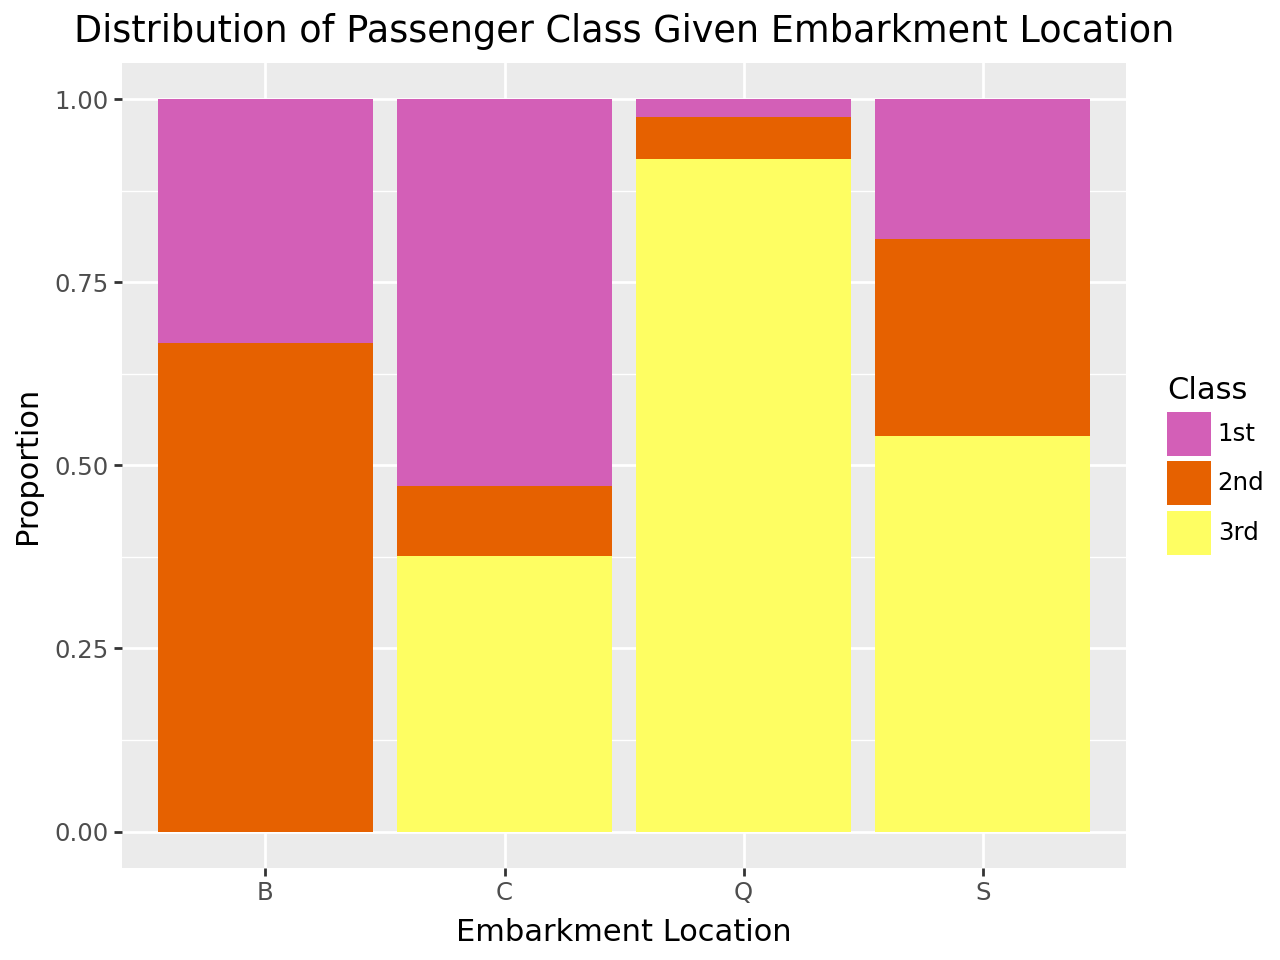

In [29]:
(ggplot(df_titanic_pass,
        aes(
            x = "embarked",
            fill = "class"
            )) +
 geom_bar(position = "fill") +
 scale_fill_manual(
     values={"1st":"#D35FB7", "2nd":"#E66100", "3rd":"#FEFE62"}) +
labs(
    x = "Embarkment Location",
    y = "Proportion",
    fill = "Class",
    title = "Distribution of Passenger Class Given Embarkment Location"
))


Pros: Answering question 2, "what proportion of Southampton passengers were in 3rd class?" is very simple and quick with this visualization. Since this visualization shows the distribution of class given one's embarkment location, we can easily answer this question by looking at the bar labeled "S" for "Southampton" and find the proportion of Southampton passengers that were in 3rd class by identifying the proportion of 3rd class passengers within this bar. So, we wouldn't have to search for this value in the conditional proportions table.

Cons: This is only a distribution for a passenger's class given their embarkment location, so it is difficult to answer the first question, "what proportion of 3rd class passengers embarked at Southampton?" without the conditional proportions table.